In [25]:
import tensorflow as tf
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns


### Data preprocessing

training image Preprocessing

In [26]:
training_set = tf.keras.utils.image_dataset_from_directory(
    'train',
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(128, 128),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
)


Found 70295 files belonging to 38 classes.


validation Image Preprocessing

In [27]:
validation_set = tf.keras.utils.image_dataset_from_directory(
    'val',
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(128, 128),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
)


Found 17572 files belonging to 38 classes.


In [28]:
training_set

<BatchDataset element_spec=(TensorSpec(shape=(None, 128, 128, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 38), dtype=tf.float32, name=None))>

In [29]:
for x,y in training_set:
    print(x,x.shape)
    print(y,y.shape)
    break

tf.Tensor(
[[[[ 73.5   64.5   66.5 ]
   [134.   123.   127.  ]
   [137.75 126.75 130.75]
   ...
   [141.25 118.25 112.25]
   [143.   120.   114.  ]
   [140.5  117.5  109.5 ]]

  [[ 75.    65.25  68.  ]
   [134.5  123.5  127.5 ]
   [130.5  119.5  123.5 ]
   ...
   [143.25 120.25 114.25]
   [143.25 120.25 114.25]
   [140.5  117.5  109.5 ]]

  [[ 69.5   60.5   62.5 ]
   [133.75 122.75 126.75]
   [129.75 118.75 122.75]
   ...
   [146.25 123.25 117.25]
   [143.25 120.25 114.25]
   [141.   118.   110.  ]]

  ...

  [[ 91.5   86.    91.5 ]
   [153.75 146.75 153.75]
   [183.5  176.5  183.5 ]
   ...
   [169.25 158.25 156.25]
   [170.75 159.75 157.75]
   [167.75 156.75 154.75]]

  [[ 89.    82.75  89.  ]
   [158.   151.   158.  ]
   [171.75 164.75 171.75]
   ...
   [166.5  155.5  153.5 ]
   [168.25 157.25 155.25]
   [165.   154.   152.  ]]

  [[ 82.5   77.    82.5 ]
   [164.5  157.5  164.5 ]
   [171.5  164.5  171.5 ]
   ...
   [167.5  156.5  154.5 ]
   [168.75 157.75 155.75]
   [169.5  158.5  15

### Building the model

In [30]:
from tensorflow.keras.layers import Dense,Conv2D,MaxPool2D,Flatten
from tensorflow.keras.models import Sequential

In [31]:
model=Sequential()

In [32]:
model.add(Conv2D(filters=32,kernel_size=(3,3),activation='relu',padding='same',input_shape=[128,128,3]))
model.add(Conv2D(filters=32,kernel_size=(3,3),activation='relu',padding='same'))
model.add(MaxPool2D(pool_size=2,strides=2))

In [33]:
model.add(Conv2D(filters=64,kernel_size=(3,3),activation='relu',padding='same'))
model.add(Conv2D(filters=64,kernel_size=(3,3),activation='relu',padding='same'))
model.add(MaxPool2D(pool_size=2,strides=2))

In [34]:
model.add(Conv2D(filters=128,kernel_size=(3,3),activation='relu',padding='same'))
model.add(Conv2D(filters=128,kernel_size=(3,3),activation='relu',padding='same'))
model.add(MaxPool2D(pool_size=2,strides=2))

In [35]:
model.add(Conv2D(filters=256,kernel_size=(3,3),activation='relu',padding='same'))
model.add(Conv2D(filters=256,kernel_size=(3,3),activation='relu',padding='same'))
model.add(MaxPool2D(pool_size=2,strides=2))

In [36]:
model.add(Flatten())

In [37]:
model.add(Dense(units=1024,activation='relu'))

In [38]:
model.add(Dense(units=38,activation='softmax'))

Compiling Model

In [39]:
model.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])

In [40]:
model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_8 (Conv2D)           (None, 128, 128, 32)      896       
                                                                 
 conv2d_9 (Conv2D)           (None, 128, 128, 32)      9248      
                                                                 
 max_pooling2d_4 (MaxPooling  (None, 64, 64, 32)       0         
 2D)                                                             
                                                                 
 conv2d_10 (Conv2D)          (None, 64, 64, 64)        18496     
                                                                 
 conv2d_11 (Conv2D)          (None, 64, 64, 64)        36928     
                                                                 
 max_pooling2d_5 (MaxPooling  (None, 32, 32, 64)       0         
 2D)                                                  

In [42]:
training_history= model.fit(x=training_set, validation_data=validation_set, epochs=10)

Epoch 1/10


2197/2197 [==============================] - 2340s 1s/step - loss: 0.3323 - accuracy: 0.8925 - val_loss: 0.2716 - val_accuracy: 0.9114
Epoch 2/10
2197/2197 [==============================] - 2334s 1s/step - loss: 0.2281 - accuracy: 0.9249 - val_loss: 0.3460 - val_accuracy: 0.8883
Epoch 3/10
2197/2197 [==============================] - 2483s 1s/step - loss: 0.1880 - accuracy: 0.9379 - val_loss: 0.2530 - val_accuracy: 0.9223
Epoch 4/10
2197/2197 [==============================] - 2399s 1s/step - loss: 0.1539 - accuracy: 0.9498 - val_loss: 0.3461 - val_accuracy: 0.9022
Epoch 5/10
2197/2197 [==============================] - 2603s 1s/step - loss: 0.1433 - accuracy: 0.9531 - val_loss: 0.2716 - val_accuracy: 0.9261
Epoch 6/10
2197/2197 [==============================] - 2519s 1s/step - loss: 0.1228 - accuracy: 0.9606 - val_loss: 0.3074 - val_accuracy: 0.9145
Epoch 7/10
2197/2197 [==============================] - 2518s 1s/step - loss: 0.1164 - accuracy: 0.9625 - val_loss: 0.3336 - val_accura

In [43]:
train_loss,train_acc=model.evaluate(training_set) 

2197/2197 [==============================] - 537s 244ms/step - loss: 0.0860 - accuracy: 0.9726


In [44]:
val_loss,val_acc=model.evaluate(validation_set) 

550/550 [==============================] - 115s 209ms/step - loss: 0.3315 - accuracy: 0.9157


In [46]:
model.save("trained_model.keras")

In [47]:
training_history.history

{'loss': [0.33234164118766785,
  0.2281482070684433,
  0.1880185455083847,
  0.1539221554994583,
  0.14331762492656708,
  0.12281422317028046,
  0.11643045395612717,
  0.11369188129901886,
  0.11209353804588318,
  0.1137080192565918],
 'accuracy': [0.8925386071205139,
  0.9248595237731934,
  0.9379045367240906,
  0.9497688412666321,
  0.9531118869781494,
  0.960594654083252,
  0.9625435471534729,
  0.9644640684127808,
  0.964293360710144,
  0.9649903774261475],
 'val_loss': [0.27164074778556824,
  0.34604892134666443,
  0.2530277967453003,
  0.346125066280365,
  0.27163517475128174,
  0.3073653280735016,
  0.33363988995552063,
  0.4409603178501129,
  0.5692707896232605,
  0.33146682381629944],
 'val_accuracy': [0.9113931059837341,
  0.8882881999015808,
  0.9223195910453796,
  0.9021739363670349,
  0.9260755777359009,
  0.9144662022590637,
  0.9120191335678101,
  0.8840769529342651,
  0.8648418188095093,
  0.9156612753868103]}

In [48]:
import json

with open("training_history.json", "w") as f:
    json.dump(training_history.history, f)

In [50]:
training_history.history["accuracy"]

[0.8925386071205139,
 0.9248595237731934,
 0.9379045367240906,
 0.9497688412666321,
 0.9531118869781494,
 0.960594654083252,
 0.9625435471534729,
 0.9644640684127808,
 0.964293360710144,
 0.9649903774261475]

In [55]:
training_history.history["val_accuracy"]

[0.9113931059837341,
 0.8882881999015808,
 0.9223195910453796,
 0.9021739363670349,
 0.9260755777359009,
 0.9144662022590637,
 0.9120191335678101,
 0.8840769529342651,
 0.8648418188095093,
 0.9156612753868103]

### Accuracy Visualization

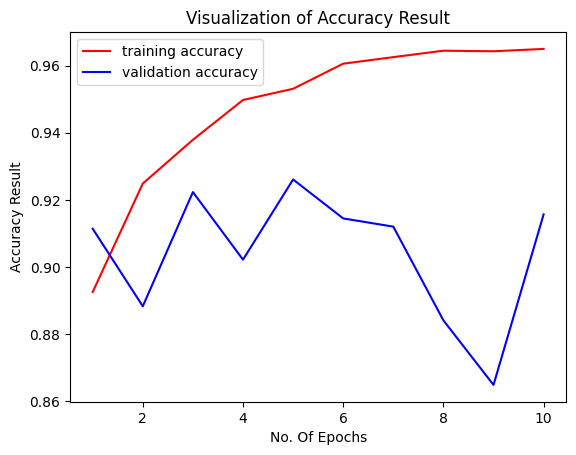

In [58]:
epochs = [i for i in range(1,11)]
plt.plot(epochs,training_history.history["accuracy"],color='red',label='training accuracy')
plt.plot(epochs,training_history.history["val_accuracy"],color='blue',label='validation accuracy')
plt.xlabel("No. Of Epochs")
plt.ylabel("Accuracy Result")
plt.title("Visualization of Accuracy Result")
plt.legend()
plt.show()

### Some other metrics for model Evaluation

In [59]:
class_name = validation_set.class_names
class_name

['Apple___Apple_scab',
 'Apple___Black_rot',
 'Apple___Cedar_apple_rust',
 'Apple___healthy',
 'Blueberry___healthy',
 'Cherry_(including_sour)___Powdery_mildew',
 'Cherry_(including_sour)___healthy',
 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot',
 'Corn_(maize)___Common_rust_',
 'Corn_(maize)___Northern_Leaf_Blight',
 'Corn_(maize)___healthy',
 'Grape___Black_rot',
 'Grape___Esca_(Black_Measles)',
 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)',
 'Grape___healthy',
 'Orange___Haunglongbing_(Citrus_greening)',
 'Peach___Bacterial_spot',
 'Peach___healthy',
 'Pepper,_bell___Bacterial_spot',
 'Pepper,_bell___healthy',
 'Potato___Early_blight',
 'Potato___Late_blight',
 'Potato___healthy',
 'Raspberry___healthy',
 'Soybean___healthy',
 'Squash___Powdery_mildew',
 'Strawberry___Leaf_scorch',
 'Strawberry___healthy',
 'Tomato___Bacterial_spot',
 'Tomato___Early_blight',
 'Tomato___Late_blight',
 'Tomato___Leaf_Mold',
 'Tomato___Septoria_leaf_spot',
 'Tomato___Spider_mites Two-spotted_

In [62]:
test_set = tf.keras.utils.image_dataset_from_directory(
    'val',
    labels="inferred",
    label_mode="categorical",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(128, 128),
    shuffle=False,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
)

Found 17572 files belonging to 38 classes.


In [61]:
y_pred = model.predict(test_set)
y_pred , y_pred.shape

550/550 [==============================] - 109s 197ms/step


(array([[9.9982846e-01, 2.1666862e-08, 4.6050822e-08, ..., 2.2862038e-08,
         2.3993380e-11, 1.7231748e-08],
        [9.9736160e-01, 8.8381256e-08, 6.7347678e-08, ..., 4.3083335e-13,
         9.9639340e-13, 2.1216140e-13],
        [9.9999964e-01, 6.6465479e-12, 1.1965167e-11, ..., 6.8631766e-14,
         6.6797522e-13, 9.0524817e-11],
        ...,
        [2.4152206e-14, 1.9610095e-20, 2.8567065e-11, ..., 2.3460524e-14,
         2.8502602e-20, 1.0000000e+00],
        [6.5031782e-12, 3.3383636e-18, 3.2249160e-13, ..., 2.5752630e-07,
         3.6317998e-18, 9.9958032e-01],
        [4.7280759e-14, 5.8072222e-17, 2.3966804e-10, ..., 4.5923803e-11,
         1.2782094e-11, 9.9944466e-01]], dtype=float32),
 (17572, 38))

In [63]:
predicted_categories = tf.argmax(y_pred,axis=1)  

In [64]:
predicted_categories

<tf.Tensor: shape=(17572,), dtype=int64, numpy=array([ 0,  0,  0, ..., 37, 37, 37], dtype=int64)>

In [66]:
true_categories = tf.concat([y for x,y in test_set], axis=0)
true_categories

<tf.Tensor: shape=(17572, 38), dtype=float32, numpy=
array([[1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.]], dtype=float32)>

In [67]:
Y_true = tf.argmax(true_categories,axis=1)
Y_true

<tf.Tensor: shape=(17572,), dtype=int64, numpy=array([ 0,  0,  0, ..., 37, 37, 37], dtype=int64)>

In [77]:
from sklearn.metrics import classification_report,confusion_matrix

In [78]:
print(classification_report(Y_true,predicted_categories,target_names=class_name))

                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.96      0.85      0.90       504
                                 Apple___Black_rot       1.00      0.94      0.97       497
                          Apple___Cedar_apple_rust       0.93      0.92      0.92       440
                                   Apple___healthy       0.91      0.86      0.88       502
                               Blueberry___healthy       0.91      0.91      0.91       454
          Cherry_(including_sour)___Powdery_mildew       0.97      0.96      0.96       421
                 Cherry_(including_sour)___healthy       0.93      0.99      0.96       456
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.89      0.90      0.90       410
                       Corn_(maize)___Common_rust_       0.99      0.99      0.99       477
               Corn_(maize)___Northern_Leaf_Blight       0.91      0.93      0.

In [81]:
cm=confusion_matrix(Y_true,predicted_categories)
cm

array([[427,   1,   1, ...,   0,   1,   0],
       [  1, 467,   2, ...,   0,   0,   0],
       [  3,   0, 405, ...,   4,   0,   2],
       ...,
       [  0,   0,   0, ..., 477,   0,   0],
       [  0,   0,   1, ...,   0, 422,   1],
       [  0,   0,   0, ...,   0,   0, 468]], dtype=int64)

### Confusion Matrix Visualization

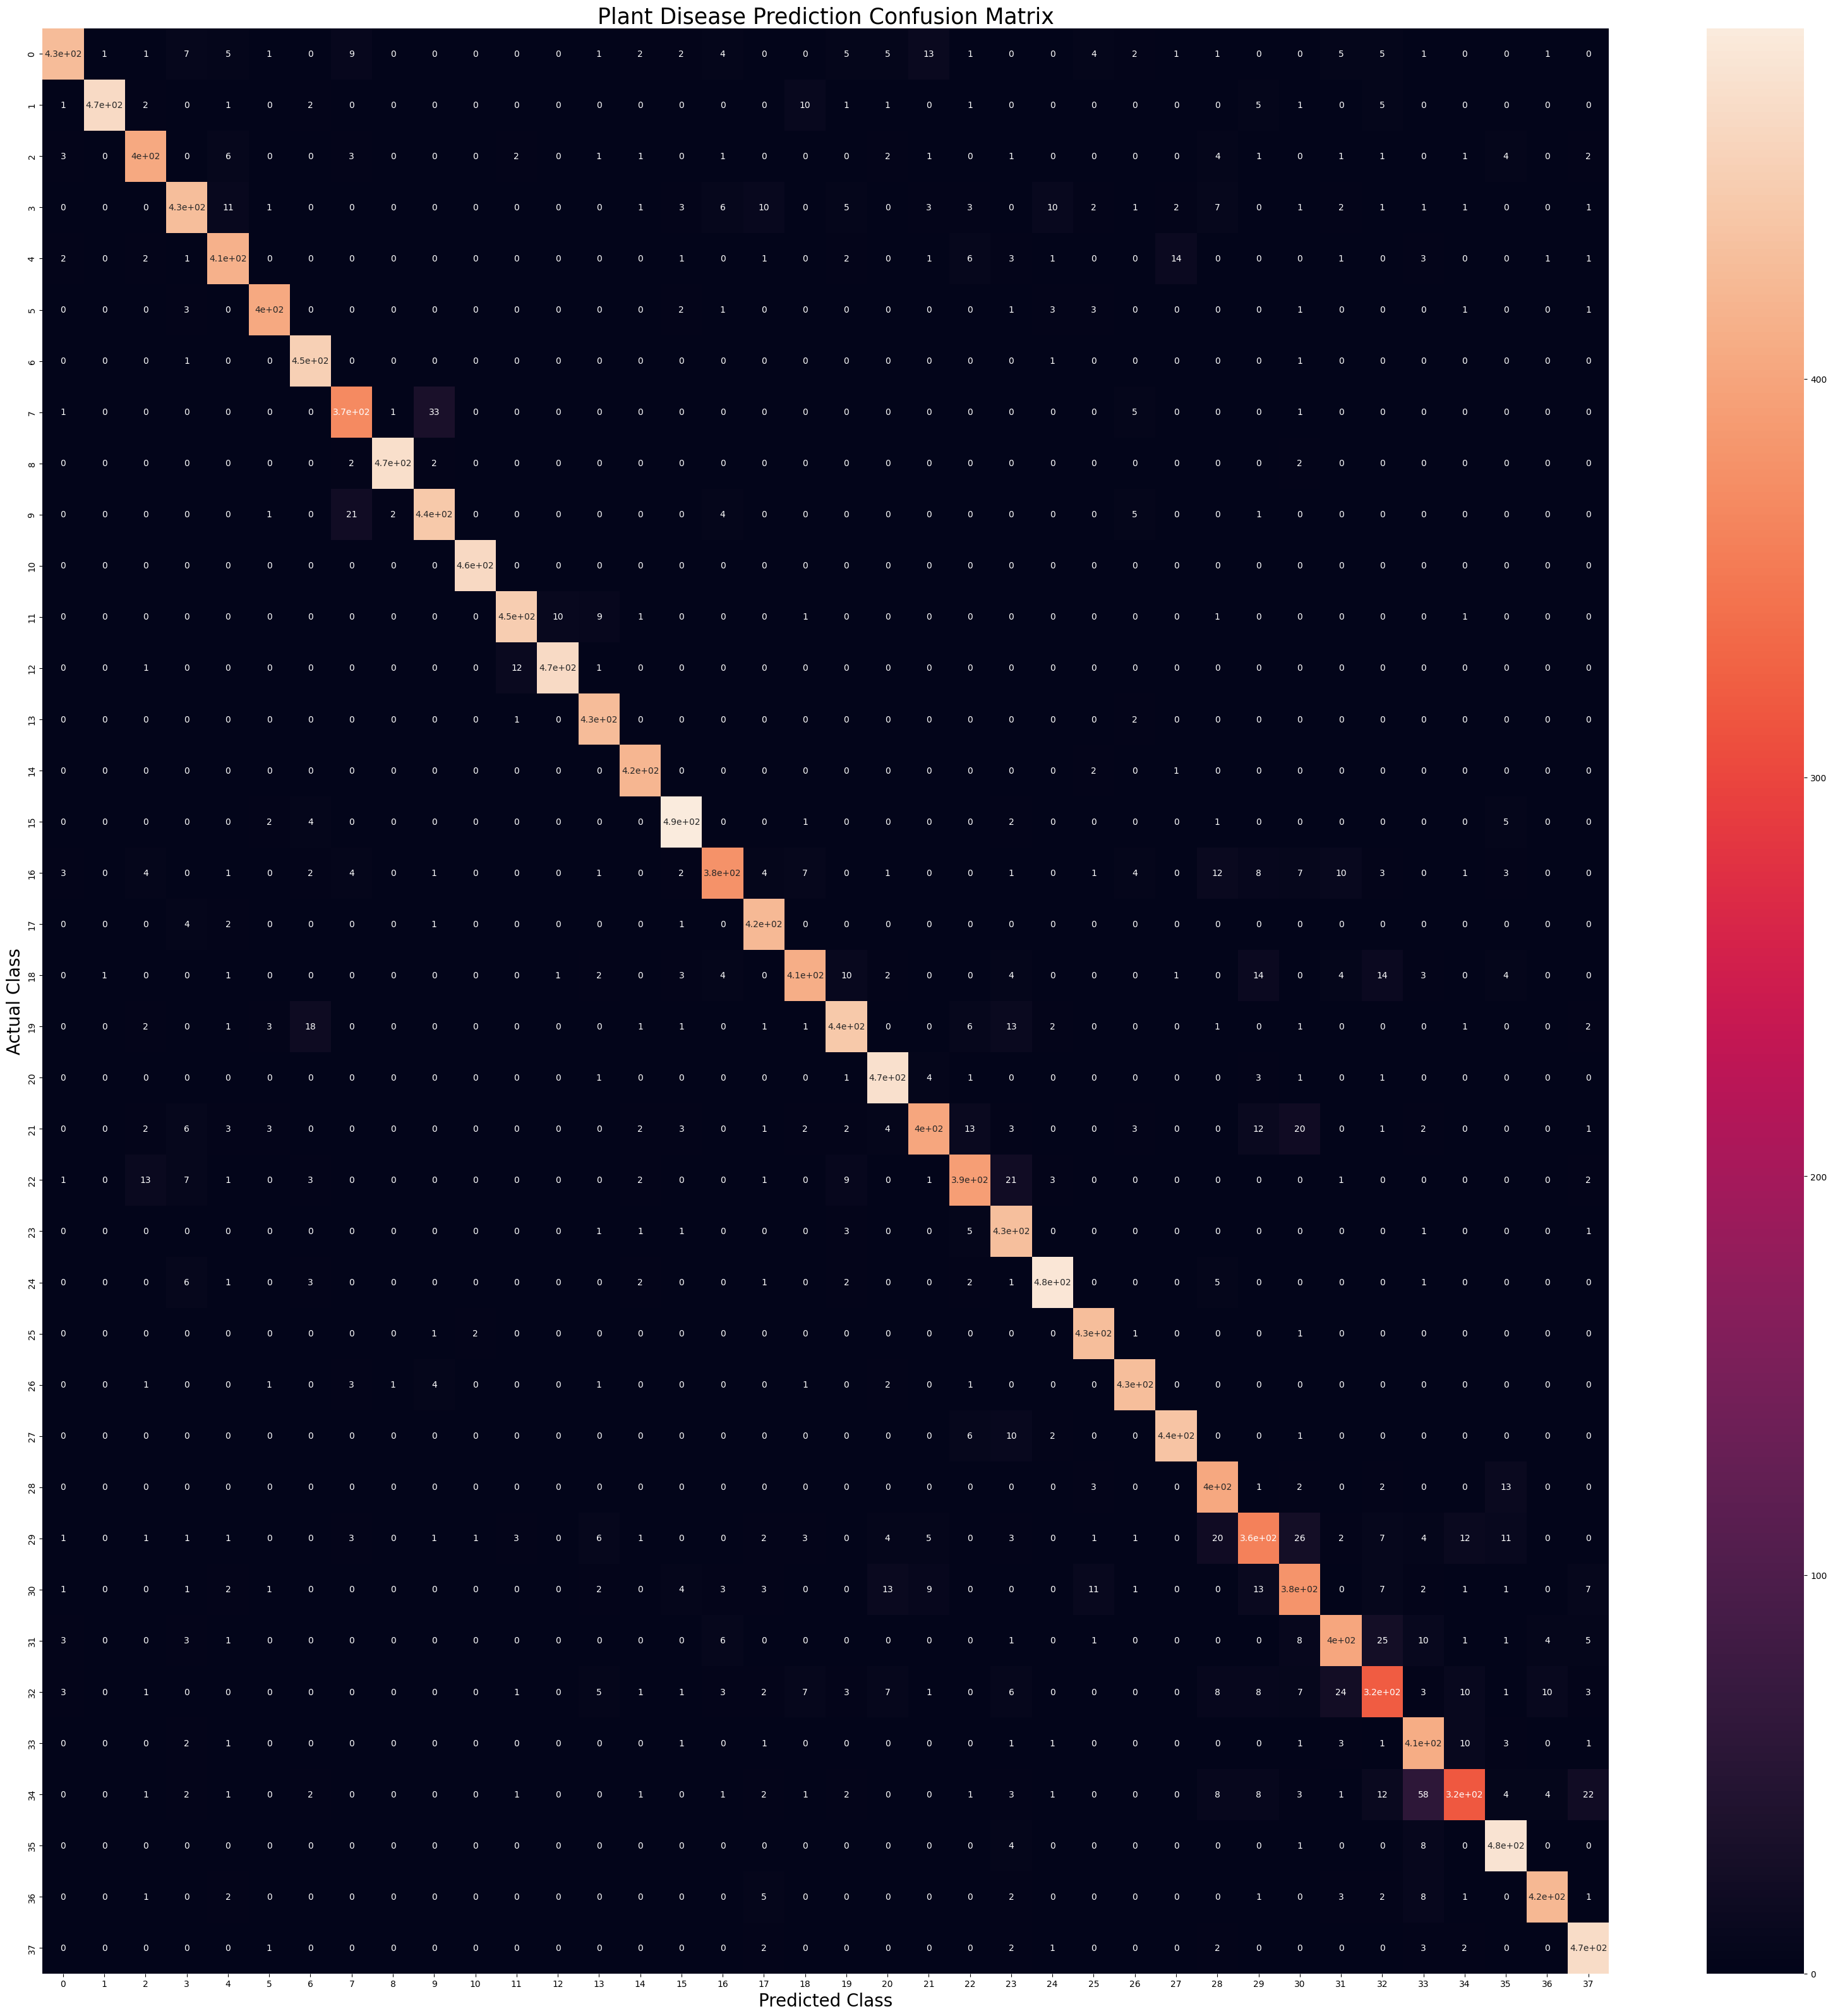

In [85]:
plt.figure(figsize=(40,40))
sns.heatmap(cm,annot=True , annot_kws={'size':10})
plt.xlabel("Predicted Class",fontsize=20)
plt.ylabel("Actual Class",fontsize=20)
plt.title("Plant Disease Prediction Confusion Matrix",fontsize=25)
plt.show()

### We are done with the model